pip install grad-cam

In [28]:
import sys
sys.path.append('..')

import os
import torch
import pandas as pd
import cv2
import numpy as np
import torch.nn as nn
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from pytorch_grad_cam import GradCAM, EigenCAM, GradCAMPlusPlus #AttentionRollout
from pytorch_grad_cam.utils.reshape_transforms import vit_reshape_transform
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.models import ResNet, VisionTransformer


from src.model import build_model

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_DIR = "../outputs/models"
TEST_CSV = "../outputs/splits/test_records.csv"
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

INV_NORMALIZE = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

In [22]:
def load_model(model_weights_path):
    checkpoint = torch.load(model_weights_path, map_location=DEVICE)
    config = checkpoint['config']
    
    num_classes = len(config.get('selected_labels', ['accidental', 'ordinary']))
    model = build_model(config, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(DEVICE)
    model.eval()
    
    model_name = config.get('model', {}).get('architecture', 'resnet50')
    label_names = config.get('selected_labels', ['accidental', 'ordinary'])
    
    print(f"  Loaded: {os.path.basename(model_weights_path)}")
    print(f"  Architecture: {model_name}")
    print(f"  Classes: {label_names}")
    
    return model, model_name, config, label_names


def load_test_data(csv_path=TEST_CSV, sample_size=None):
    df = pd.read_csv(csv_path)
    
    labels = sorted(df["label"].unique())
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}
    
    df["label_index"] = df["label"].map(label_to_index)
    df["index_to_label"] = df["label"].map(index_to_label)
    
    if sample_size:
        df = df.sample(n=min(sample_size, len(df)), random_state=42).reset_index(drop=True)
    
    print(f"  Loaded {len(df)} test samples")
    print(f"  Label distribution:\n{df['label'].value_counts().to_string()}")
    
    return df

def get_cam(model, model_name):
    
    if isinstance(model, ResNet):
        target_layers = [model.layer4[-1]]

        cam = GradCAM(
            model=model,
            target_layers=target_layers
        )
        return cam, "Grad-CAM"

    elif isinstance(model, VisionTransformer):
        target_layers = [model.encoder.layers[-1].ln_1]

        # cam = EigenCAM(
        cam = GradCAM(
            model=model,
            target_layers=target_layers,
            reshape_transform=vit_reshape_transform
        )
        return cam, "EigenCAM"

    else:
        raise ValueError(
            f"Unsupported architecture: {type(model)}"
        )

def generate_explanation(model, model_name, df, index, label_names=None, save_path=None):
    if label_names is None:
        label_names = sorted(df["label"].unique())

    index_to_label = {idx: label for idx, label in enumerate(label_names)}

    # Load image and label
    row = df.iloc[index]
    image_path = row["path"]
    true_label = row["label"]
    true_index = row["label_index"]

    # Preprocess
    image = Image.open("../" + image_path).convert("RGB")
    input_tensor = EVAL_TRANSFORM(image).unsqueeze(0).to(DEVICE)

    # Get prediction
    model.eval()

    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_index = outputs.argmax(dim=1).item()
    confidence = probs[0, pred_index].item()

    pred_label = index_to_label.get(pred_index, str(pred_index))
    is_correct = pred_index == true_index

    # Get CAM extractor
    cam, cam_method = get_cam(model, model_name)

    # Generate heatmap
    input_tensor.requires_grad_(True)

    targets = [ClassifierOutputTarget(pred_index)]
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )
    grayscale_cam = grayscale_cam[0, :]

    # Convert tensor to displayable RGB image
    rgb_img = (
        INV_NORMALIZE(input_tensor[0])
        .detach()
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )
    rgb_img = np.clip(rgb_img, 0, 1).astype(np.float32)

    # Overlay
    overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(rgb_img)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title(f"Heatmap\n({cam_method})", fontsize=13)
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\nPred: {pred_label} ({confidence:.1%})", fontsize=13)
    axes[2].axis("off")

    status = "✓ Correct" if is_correct else "✗ Wrong"
    fig.suptitle(
        f"{status}  |  True: {true_label}  |  Pred: {pred_label}  |  Conf: {confidence:.1%}",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    plt.close()

    return {
        "image_path": image_path,
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": confidence,
        "correct": is_correct
    }

In [20]:
test_df = load_test_data(sample_size=50)

  Loaded 50 test samples
  Label distribution:
label
ordinary      32
accidental    18


  Loaded: vit_oversample.pt
  Architecture: resnet50
  Classes: ['ordinary', 'accidental']
Saved: ../outputs/figures/{model_name}_{index}.png


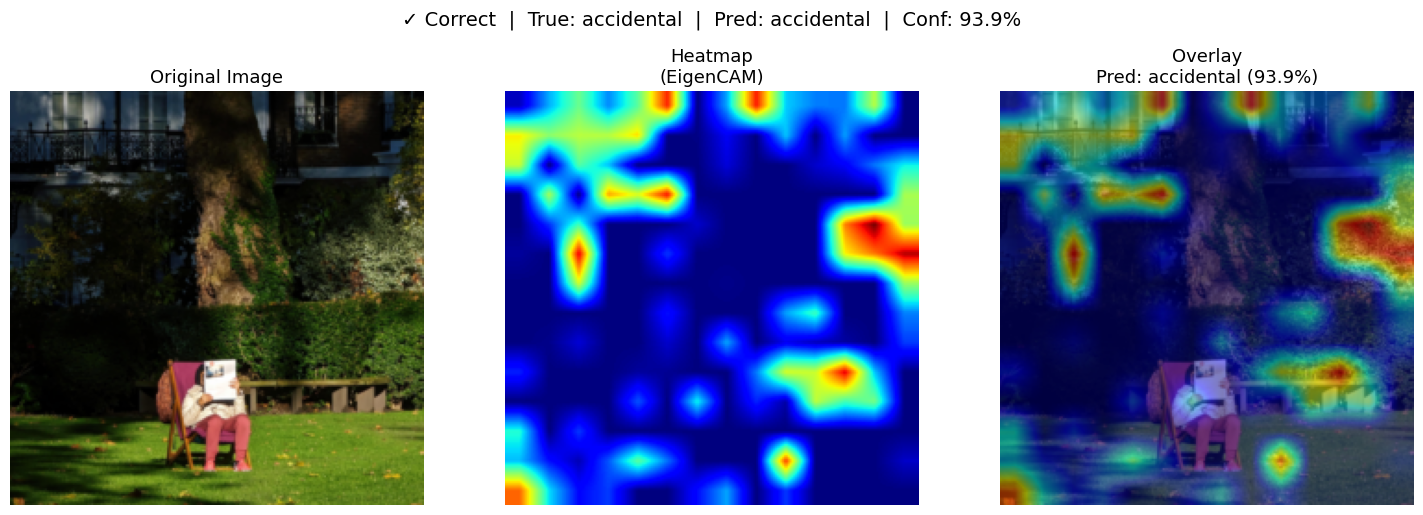


Result: {'image_path': 'data\\raw\\reddit_data\\8962f2957da34d32.jpg', 'true_label': 'accidental', 'pred_label': 'accidental', 'confidence': 0.9387926459312439, 'correct': np.True_}
  Loaded: resnet_none.pt
  Architecture: resnet50
  Classes: ['ordinary', 'accidental']
Saved: ../outputs/figures/{model_name}_{index}.png


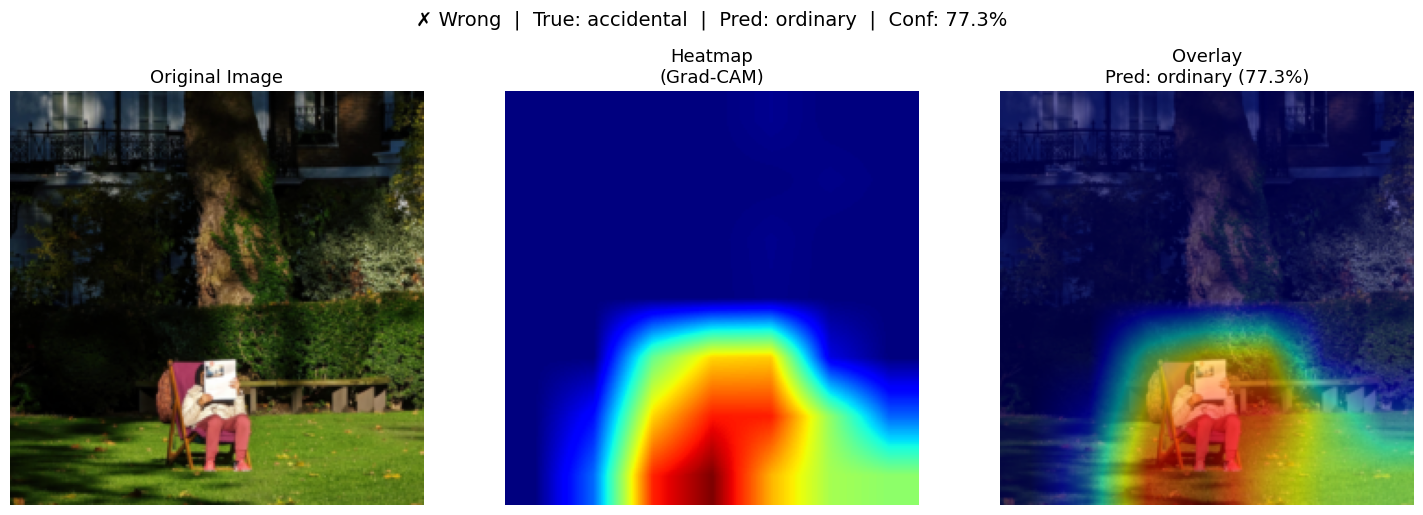


Result: {'image_path': 'data\\raw\\reddit_data\\8962f2957da34d32.jpg', 'true_label': 'accidental', 'pred_label': 'ordinary', 'confidence': 0.7732954025268555, 'correct': np.False_}


In [ ]:

model, model_name, config, label_names = load_model("../outputs/models/vit_oversample.pt")

result = generate_explanation(
    model=model,
    model_name=model_name,
    df=test_df,
    index=45,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")

model, model_name, config, label_names = load_model("../outputs/models/resnet_none.pt")

result = generate_explanation(
    model=model,
    model_name=model_name,
    df=test_df,
    index=45,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")

Saved: ../outputs/figures/resnet50.png


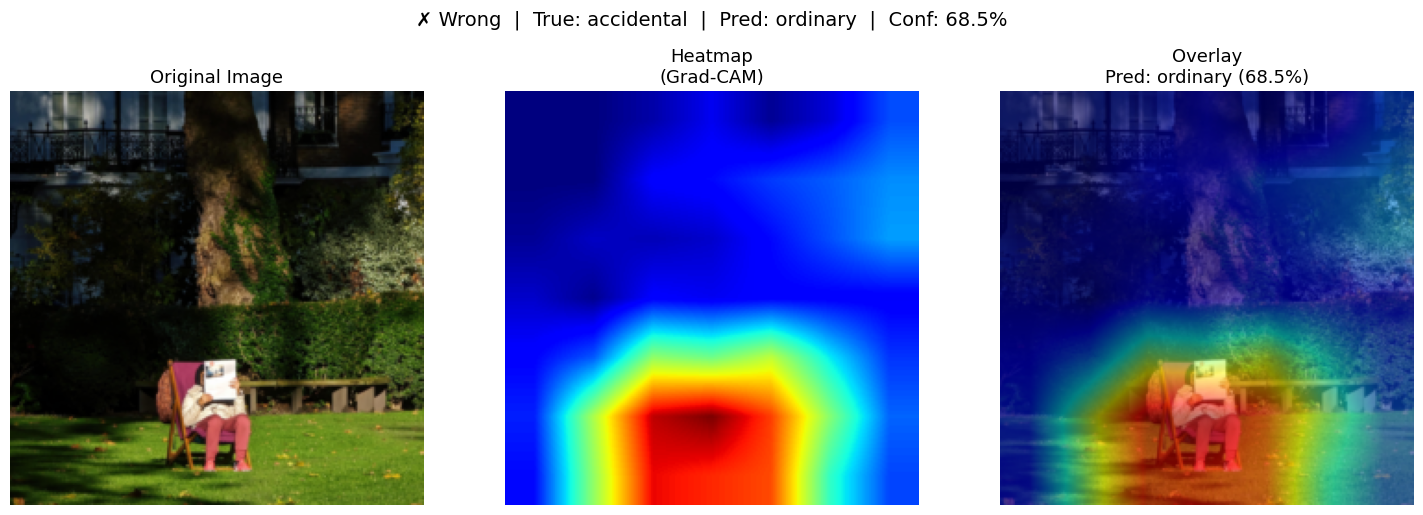


Result: {'image_path': 'data\\raw\\reddit_data\\8962f2957da34d32.jpg', 'true_label': 'accidental', 'pred_label': 'ordinary', 'confidence': 0.684628427028656, 'correct': np.False_}
Saved: ../outputs/figures/resnet50.png


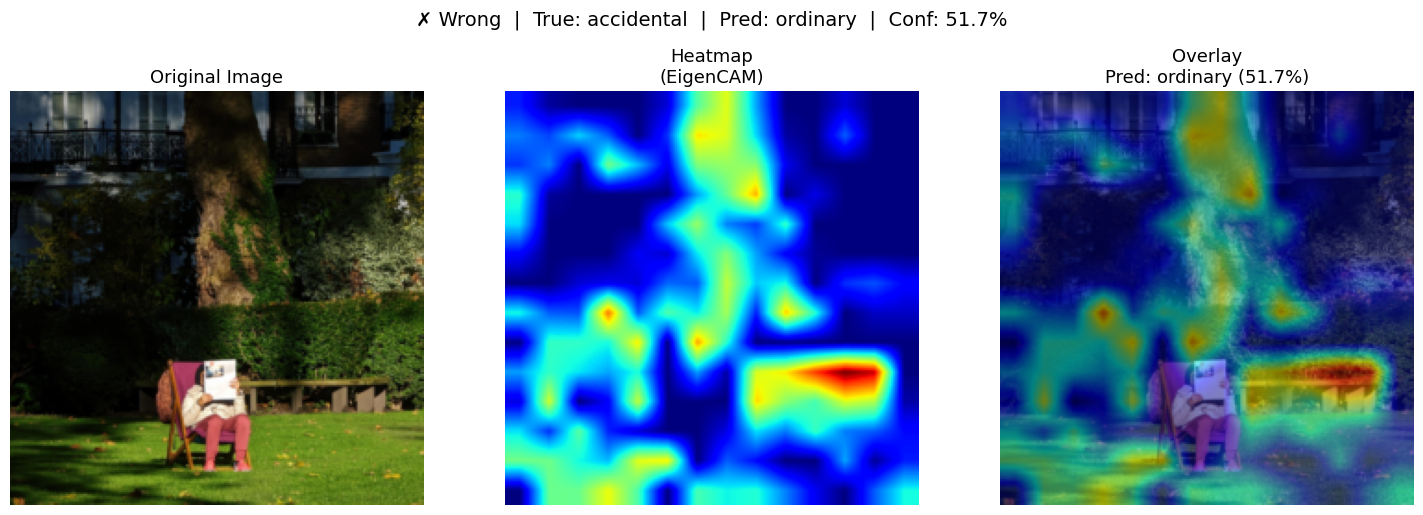


Result: {'image_path': 'data\\raw\\reddit_data\\8962f2957da34d32.jpg', 'true_label': 'accidental', 'pred_label': 'ordinary', 'confidence': 0.5167222023010254, 'correct': np.False_}


In [29]:
# random_model = resnet50(weights=None)
random_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
random_model.fc = nn.Linear(random_model.fc.in_features, 2)

random_model = random_model.to(DEVICE)
random_model.eval()

result = generate_explanation(
    model=random_model,
    model_name="random_resnet",
    df=test_df,
    index=45,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")

# random_vit = vit_b_16(weights=None)
random_vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
random_vit.heads.head = nn.Linear(
    random_vit.heads.head.in_features,
    2
)

random_vit = random_vit.to(DEVICE)
random_vit.eval()

result = generate_explanation(
    model=random_vit,
    model_name="random_vit",
    df=test_df,
    index=45,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")